In [1]:
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import pandas as pd

# Data Load

In [2]:
from sklearn.preprocessing import MinMaxScaler

In [3]:
# loading sound level data; shape (1388, 689, 59, 1)
# data = np.load('sound_levels_data.npy')
# data = np.load('../data/02_intermediate/soundlevel_normal.npy')
data = np.load('../data/02_intermediate/soundlevel_19.npy')
print(data.shape)

position_indices = np.arange(689)
values = 60 + 10 * position_indices  
#print(values)

valid_positions = np.where(values >= 1260)[0]
print(valid_positions)

reshaped_data = data[:, valid_positions, :, :]
print(reshaped_data.shape)

scaler = MinMaxScaler()
X_train_normalized = scaler.fit_transform(reshaped_data.reshape(-1, reshaped_data.shape[-1])).reshape((reshaped_data.shape[0], reshaped_data.shape[2], reshaped_data.shape[1]))

X_train_normalized.shape

(1388, 689, 59, 1)
[120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137
 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155
 156 157 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173
 174 175 176 177 178 179 180 181 182 183 184 185 186 187 188 189 190 191
 192 193 194 195 196 197 198 199 200 201 202 203 204 205 206 207 208 209
 210 211 212 213 214 215 216 217 218 219 220 221 222 223 224 225 226 227
 228 229 230 231 232 233 234 235 236 237 238 239 240 241 242 243 244 245
 246 247 248 249 250 251 252 253 254 255 256 257 258 259 260 261 262 263
 264 265 266 267 268 269 270 271 272 273 274 275 276 277 278 279 280 281
 282 283 284 285 286 287 288 289 290 291 292 293 294 295 296 297 298 299
 300 301 302 303 304 305 306 307 308 309 310 311 312 313 314 315 316 317
 318 319 320 321 322 323 324 325 326 327 328 329 330 331 332 333 334 335
 336 337 338 339 340 341 342 343 344 345 346 347 348 349 350 351 352 353
 354 355 356 357 358 359 360 361

(1388, 59, 569)

In [16]:
np.max(reshaped_data)

np.float64(72.13738655233209)

In [17]:
# _1_1_scaler = MinMaxScaler(feature_range=(-1,1))
# X_train_normalized_1 = _1_1_scaler.fit_transform(reshaped_data.reshape(-1, reshaped_data.shape[-1])).reshape((reshaped_data.shape[0], reshaped_data.shape[2], reshaped_data.shape[1]))

In [18]:
import tensorflow as tf
print(tf.__version__)

2.18.0


# Model Implementation

In [19]:
import keras
from keras.models import Model, Sequential
from keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense, Dropout, Attention
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
from keras.regularizers import l2
from keras.losses import Huber

In [20]:
def build_model():

    input_shape = (59, 569)  # (time_steps, features)

    # Encoder
    input_seq = Input(shape=input_shape)

    # encoded = LSTM(256, activation='relu', return_sequences=True)(input_seq)  # adding more layers - will come back to it,for now not looking so good
    encoded = LSTM(128, activation='relu', return_sequences=True)(input_seq) 
    encoded = LSTM(64, activation='relu', return_sequences=False)(encoded)  
    
    encoded = Dropout(0.2)(encoded) # remove dropout layers - makes it a bit worse; change to 0.1 - gets worse in the second half of the time series
    
    # Latent space
    latent_space = Dense(128, activation='relu')(encoded) # change to 64 - not much of a difference; change to 256 - even worse

    # Decoder
    decoded = RepeatVector(input_shape[0])(latent_space)  
    decoded = LSTM(64, activation='relu', return_sequences=True)(decoded)
    decoded = LSTM(128, activation='relu', return_sequences=True)(decoded)
    # decoded = LSTM(256, activation='relu', return_sequences=True)(decoded) 
    decoded = Dropout(0.2)(decoded) # here 0.1, up 0.3 - error spikes up; here 0.1, up 0.2 - still bad 

    decoded = TimeDistributed(Dense(input_shape[1]))(decoded) # adding sigmoid activation -  made it only worse

    model = Model(input_seq, decoded)

    # lr to 0.001 (increase) - horrible, loss skyrockets; lr to 0.0001 - slightly worse than the original model
    model.compile(optimizer=Adam(learning_rate=0.0001), loss="mse") # trying MAE instead - made it worse; Hubert loss - the second half of the time series is not even trying to get reconstructed

    return model

In [21]:
def build_old_model():

    input_shape = (59, 569)  # (time_steps, features)

    # Encoder
    input_seq = Input(shape=input_shape)
    encoded = LSTM(128, activation='relu', return_sequences=True)(input_seq) 
    encoded = LSTM(64, activation='relu', return_sequences=False)(encoded)  
    encoded = Dropout(0.2)(encoded)

    # Latent space
    latent_space = Dense(128, activation='relu')(encoded)

    # Decoder
    decoded = RepeatVector(input_shape[0])(latent_space)  
    decoded = LSTM(64, activation='relu', return_sequences=True)(decoded)
    decoded = LSTM(128, activation='relu', return_sequences=True)(decoded)
    decoded = Dropout(0.2)(decoded)

    decoded = TimeDistributed(Dense(input_shape[1]))(decoded)

    model = Model(input_seq, decoded)

    model.compile(optimizer=Adam(learning_rate=0.0005), loss='mse')

    return model

In [104]:
model = build_old_model()
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 59, 569)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 59, 128)        │       357,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_2 (RepeatVector)  │ (None, 59, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 59, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 59, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 59, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 59, 569)        │        73,401 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 636,729 (2.43 MB)

 Trainable params: 636,729 (2.43 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 341ms/step - loss: 0.0578 - val_loss: 0.0539
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 182ms/step - loss: 0.0558 - val_loss: 0.0490
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 185ms/step - loss: 1314.6262 - val_loss: 0.0471
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - loss: 0.0502 - val_loss: 0.0476
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - loss: 0.0503 - val_loss: 0.0472
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - loss: 0.0495 - val_loss: 0.0456
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 207ms/step - loss: 0.0476 - val_loss: 0.0425
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 188ms/step - loss: 528.3294 - val_loss: 71984.0078
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 185ms/step - loss: 2088814.0000 - val_loss: 0.0404
Epoch 10/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 186ms/step - loss: 0.2984 - val_loss: 0.0415
Epoch 11/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 193ms/step - loss: 0.0454 - val_loss: 0.0417
Epoch 12/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 191ms/s

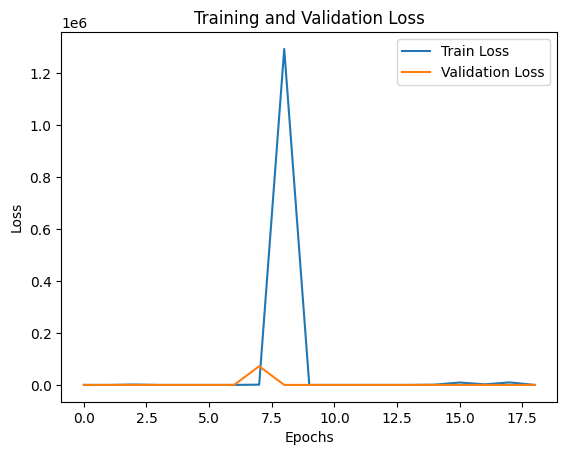

In [45]:
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(X_train_normalized, X_train_normalized, epochs=200, batch_size=64, validation_split=0.2, callbacks=[early_stopping])

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

In [22]:
# model = keras.models.load_model('models/relu_[0-1]_model.keras')
model = keras.models.load_model('../data/06_models/keras_model.keras')
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 59, 569)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 59, 128)        │       357,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 59, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 59, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 59, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 59, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 59, 569)        │        73,401 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,910,189 (7.29 MB)

 Trainable params: 636,729 (2.43 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,273,460 (4.86 MB)

In [23]:
reconstructed_data = model.predict(X_train_normalized)

# Calculate reconstruction error
reconstruction_error = np.abs(X_train_normalized - reconstructed_data)

44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step


In [24]:
mean_abs_error = np.mean(abs(X_train_normalized - reconstructed_data))
print(mean_abs_error)

0.06422127089635013


In [25]:
def plot_original_reconstructed(sample_idx, location, original_series, reconstructed_series, save_path=None):

    feature_idx = int((location - 1260)/10)

    original_series = original_series[sample_idx, :, feature_idx]
    reconstructed_series = reconstructed_series[sample_idx, :, feature_idx]

    plt.figure(figsize=(8, 5))
    plt.plot(original_series, label="Original", linestyle="--", marker="o", color="royalblue")
    plt.plot(reconstructed_series, label="Reconstructed", linestyle="-", marker="s", color="darkorange")

    plt.xlabel("Time Step")
    plt.ylabel("Feature Value")
    plt.title(f"Original vs. Reconstructed Series (Location {location})")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close()  
    else:
        plt.show()

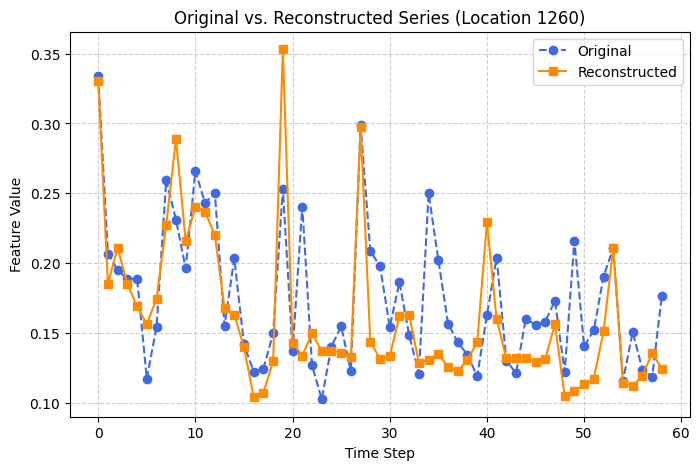

In [26]:
plot_original_reconstructed(200, 1260, X_train_normalized, reconstructed_data)

In [27]:
def plot_filtered(errors):
    position_indices = np.arange(569) 
    values = 1260 + 10 * position_indices  

    valid_positions = np.where((values >= 4200) & (values <= 4300))[0]

    filtered_errors = errors[:, :, valid_positions].flatten()

    plt.figure(figsize=(8, 5))
    plt.hist(filtered_errors, bins=50, color="pink", edgecolor="black", alpha=0.75)
    plt.xlabel("Reconstruction Error", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.title("Distribution of Reconstruction Errors (4200-4300)", fontsize=14)
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.show()


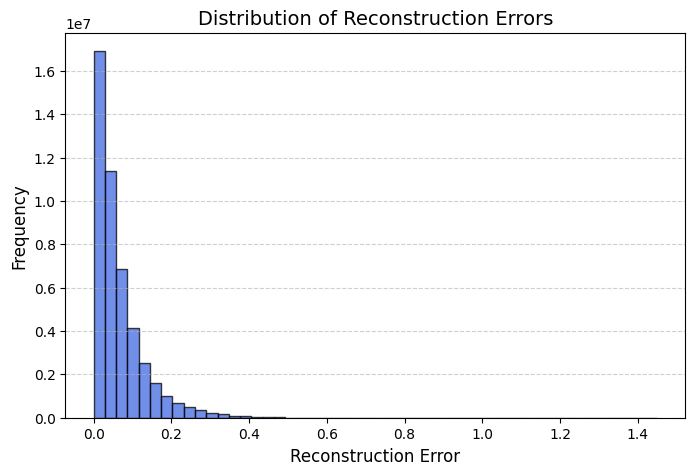

In [28]:
flat_reconstruction_error = reconstruction_error.flatten()

plt.figure(figsize=(8, 5))
plt.hist(flat_reconstruction_error, bins=50, color="royalblue", edgecolor="black", alpha=0.75)
plt.xlabel("Reconstruction Error", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Distribution of Reconstruction Errors", fontsize=14)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

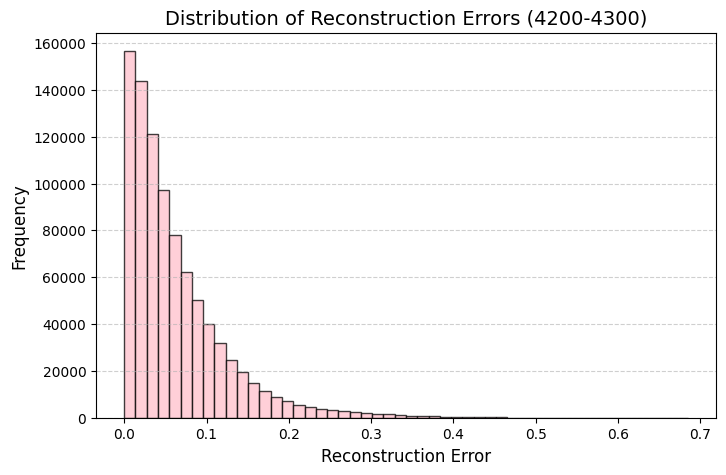

In [29]:
plot_filtered(reconstruction_error)

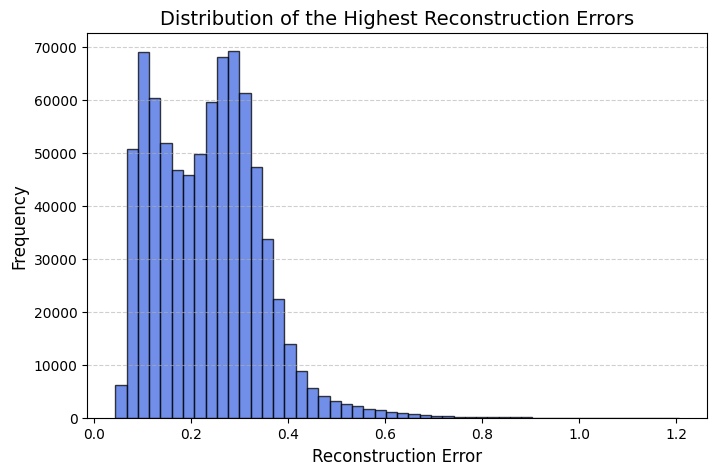

In [30]:
reconstruction_error_99p = np.percentile(reconstruction_error, q=99, axis=1)
flat_reconstruction_error_99p = reconstruction_error_99p.flatten()

plt.figure(figsize=(8, 5))
plt.hist(flat_reconstruction_error_99p, bins=50, color="royalblue", edgecolor="black", alpha=0.75)
plt.xlabel("Reconstruction Error", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Distribution of the Highest Reconstruction Errors", fontsize=14)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

In [31]:
reconstruction_error_99p.shape

(1388, 569)

In [33]:
thresholds = np.percentile(reconstruction_error_99p, q=99, axis=0)
thresholds

array([0.43085822, 0.41113584, 0.46116305, 0.4685205 , 0.4343004 ,
       0.42160879, 0.42493671, 0.42417311, 0.44285886, 0.41651849,
       0.42903336, 0.4122553 , 0.4759669 , 0.41672731, 0.44638219,
       0.44069142, 0.43290288, 0.42692558, 0.43166422, 0.41269908,
       0.43408742, 0.42309663, 0.4204674 , 0.4190777 , 0.42706863,
       0.43365223, 0.45895473, 0.45125264, 0.43734416, 0.46125854,
       0.46524615, 0.43364861, 0.45901542, 0.43856186, 0.41883733,
       0.44169267, 0.42270444, 0.45429979, 0.43595144, 0.45194637,
       0.4404966 , 0.44180761, 0.43623966, 0.42596309, 0.46403096,
       0.44175979, 0.41748339, 0.45138597, 0.43547771, 0.43165715,
       0.44113346, 0.38043567, 0.38355209, 0.38942159, 0.39205385,
       0.4012843 , 0.41078821, 0.41292979, 0.3838153 , 0.38901734,
       0.38002852, 0.38856376, 0.39787214, 0.3891718 , 0.3875466 ,
       0.39692017, 0.39888893, 0.39109767, 0.37293395, 0.3631845 ,
       0.39094312, 0.38106001, 0.37134961, 0.33007927, 0.35064

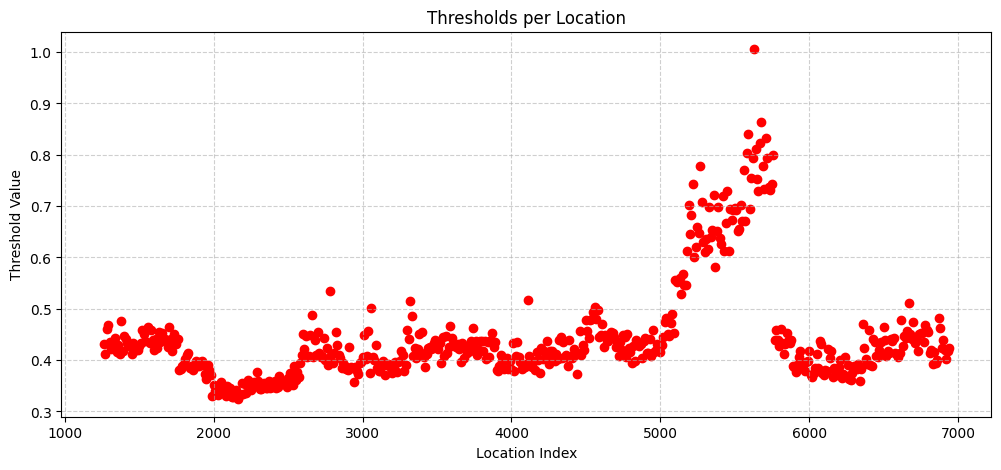

In [34]:
position_indices = np.arange(569) 
values = 1260 + 10 * position_indices 
plt.figure(figsize=(12, 5))
plt.scatter(values, thresholds, color='red', marker='o')
plt.xlabel("Location Index")
plt.ylabel("Threshold Value")
plt.title("Thresholds per Location")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


# Different Models Trials

In [ ]:
model_relu_loaded = keras.models.load_model('models/relu_[0-1]_model.keras')
relu_reconstructed_data_loaded = model_relu_loaded.predict(X_train_normalized)

In [ ]:
model_tanh_loaded = keras.models.load_model('models/tanh_[-1_1]_model.keras')
tanh_reconstructed_data_loaded = model_tanh_loaded.predict(X_train_normalized_1)

In [ ]:
plot_original_reconstructed(200, 5000, X_train_normalized, relu_reconstructed_data_loaded)
# plot_original_reconstructed(1000, 4200, X_train_normalized_1, tanh_reconstructed_data_loaded)

In [ ]:
error_first = np.mean(abs(X_train_normalized - relu_reconstructed_data_loaded))
error_second = np.mean(abs(X_train_normalized_1 - tanh_reconstructed_data_loaded))

print("First plot MSE:", error_first)
print("Second plot MSE:", error_second)


# Anomaly Data Trial

In [35]:
# data = np.load('25_event_day.npy', allow_pickle=True)
data = np.load('../data/02_intermediate/soundlevel_25.npy', allow_pickle=True)
#data
X_data = np.stack(data['data'], axis=0)
X_data.shape

(5, 569, 59, 1)

In [36]:
data['filename'][0]

np.str_('2021_02_25_09h59m51s')

In [37]:
X_test_normalised = scaler.transform(X_data.reshape(-1, X_data.shape[-1])).reshape((X_data.shape[0], X_data.shape[2], X_data.shape[1]))
X_test_normalised.shape

(5, 59, 569)

In [38]:
np.max(X_data)

np.float64(59.58837571751537)

In [39]:
reconstructed_anom_data = model.predict(X_test_normalised)
reconstruction_anom_error = np.abs(X_test_normalised - reconstructed_anom_data)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


In [58]:
reconstruction_anom_error

array([[[0.12271219, 0.13720326, 0.07108366, ..., 0.05477702,
         0.03446301, 0.00059632],
        [0.01785632, 0.04883314, 0.08640261, ..., 0.00260028,
         0.05106884, 0.03990741],
        [0.06780214, 0.03457841, 0.08288727, ..., 0.05019681,
         0.0527398 , 0.07096916],
        ...,
        [0.03914546, 0.25428662, 0.35719825, ..., 0.13454812,
         0.14821859, 0.15853056],
        [0.15889231, 0.0897235 , 0.10590714, ..., 0.06638984,
         0.08097153, 0.053829  ],
        [0.1591513 , 0.10871085, 0.18251698, ..., 0.10754364,
         0.13358244, 0.10538146]],

       [[0.03094727, 0.08666977, 0.11200368, ..., 0.07703831,
         0.13638087, 0.1435022 ],
        [0.08068134, 0.06588184, 0.03103767, ..., 0.052235  ,
         0.08141378, 0.063973  ],
        [0.08643567, 0.05325722, 0.09772331, ..., 0.11231294,
         0.07033074, 0.11266857],
        ...,
        [0.26782699, 0.1120058 , 0.05833766, ..., 0.17395438,
         0.12943332, 0.11550439],
        [0.1

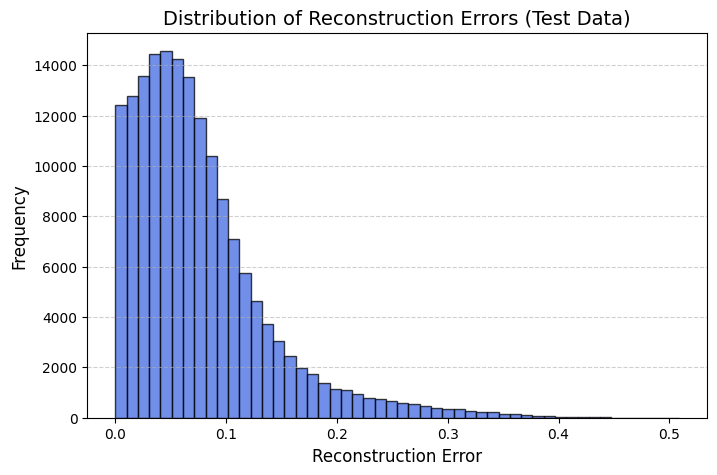

In [59]:
anom_flat_reconstruction_error = reconstruction_anom_error.flatten()

plt.figure(figsize=(8, 5))
plt.hist(anom_flat_reconstruction_error, bins=50, color="royalblue", edgecolor="black", alpha=0.75)
plt.xlabel("Reconstruction Error", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Distribution of Reconstruction Errors (Test Data)", fontsize=14)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

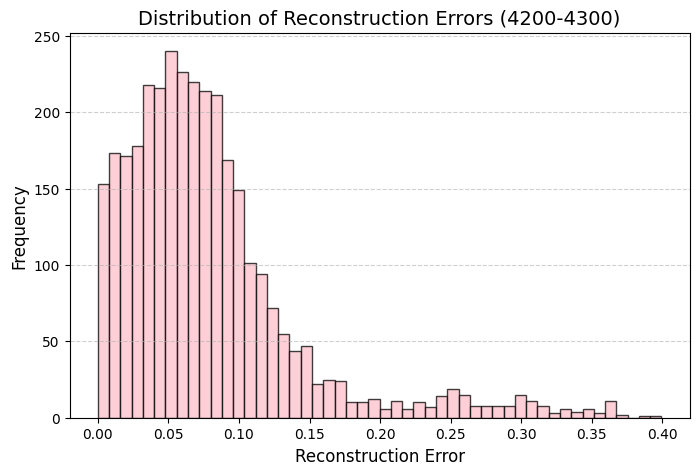

In [60]:
plot_filtered(reconstruction_anom_error)

In [61]:
reconstruction_anom_error.shape

(5, 59, 569)

In [62]:
thresholds.shape

(569,)

In [63]:
reconstruction_anom_error_99p = np.percentile(reconstruction_anom_error, q=99, axis=1)
reconstruction_anom_error_99p.shape

(5, 569)

In [74]:
anomalies = reconstruction_anom_error_99p[:, :] > thresholds
anomalies.shape


(5, 569)

In [65]:
anomalies[4][50]

np.False_

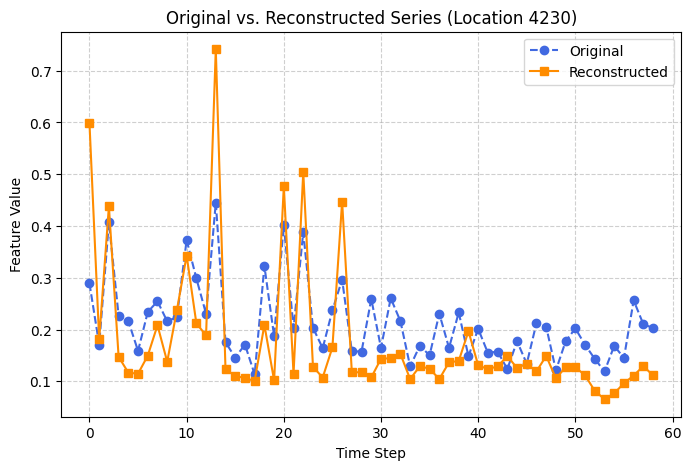

In [66]:
plot_original_reconstructed(0, 4230, X_test_normalised, reconstructed_anom_data)

In [67]:
save_folder = "other_anomaly_plots"
import os
os.makedirs(save_folder, exist_ok=True)
anomaly_indices = np.where(anomalies)

counter = 0
for sample, position in zip(anomaly_indices[0], anomaly_indices[1]):
    filename = f"{save_folder}/anomaly_{data['filename'][sample]}_pos_{1260 + 10*position}.png"
    print(f"Anomaly detected at sample {sample} {data['filename'][sample]}, position {1260 + 10*position}")
    
    plot_original_reconstructed(sample, 1260 + 10*position, X_test_normalised, reconstructed_anom_data, save_path=filename)
    
    counter += 1
    if counter == 50:
        break

Anomaly detected at sample 4 2021_02_25_10h03m51s, position 1770


In [70]:
event_table = pd.read_csv("../data/01_raw/events_table.csv", parse_dates=["start", "end"])

In [72]:
from datetime import datetime, timedelta

save_folder = "anomaly_plots"
import os
os.makedirs(save_folder, exist_ok=True)
anomaly_indices = np.where(anomalies)

def is_anomaly_in_event(anomaly_time, anomaly_position, event_start, event_end, event_poi):
    return event_start <= anomaly_time <= event_end and anomaly_position in event_poi

for sample, position in zip(anomaly_indices[0], anomaly_indices[1]):
    file_time_str = data['filename'][sample]  
    anomaly_time = datetime.strptime(file_time_str, "%Y_%m_%d_%Hh%Mm%Ss")
    
    anomaly_end_time = anomaly_time + timedelta(minutes=1)
    
    anomaly_position = 1260 + 10 * position
    
    for _, event in event_table.iterrows():  
        event_start = pd.Timestamp(event['start'], "%Y-%m-%d %H:%M:%S")
        event_end = pd.Timestamp(event['end'], "%Y-%m-%d %H:%M:%S")
        event_poi = set(map(int, event['poi'].split(',')))  

        if is_anomaly_in_event(anomaly_time, anomaly_position, event_start, event_end, event_poi) or \
           is_anomaly_in_event(anomaly_end_time, anomaly_position, event_start, event_end, event_poi):
            print(f"Anomaly detected at {anomaly_time} matches event {event['label_anon']} at {event_start} ending at {event_end} (Position: {anomaly_position})")
            # filename = f"{save_folder}/anomaly_{data['filename'][sample]}_pos_{1260 + 10*position}.png"
            # plot_original_reconstructed(sample, 1260 + 10*position, X_test_normalised, reconstructed_anom_data, save_path=filename)



# Non AI